In [ ]:

#Building a simple LLM agent using Long Chain and Tool Calling

In [ ]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 984.2/984.2 kB 15.4 MB/s eta 0:00:00


In [ ]:
#configure api key
import os
from google.colab import userdata
os.environ["GOOGLE_API_KEY"] = userdata.get("apikey1")

In [ ]:
from google import genai
client = genai.Client()

In [ ]:
def calculator(expression: str):
  return eval(expression)

In [ ]:
response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents="What is (22+10) * 5?",
    config={
        "tools": [calculator]
    }
)
print(response.text)

(22+10) * 5 is 160.


In [ ]:
#UNIT-5:EXPERIMENT-14:Multimodel Prompting Exploration:
#generate images from detailed text prompts;feed one generated image into an image-understanding model or api with an appropriate prompt.

In [ ]:
original_prompt = """ A futuristic classroom where an AI humanoid robot teaches Python programming to engineering students. The classroom has - Blue ambient lighting - Interactive holographic displays - Large digital screens - Students working on laptops - Modern smart classroom - Ultra realistic"""

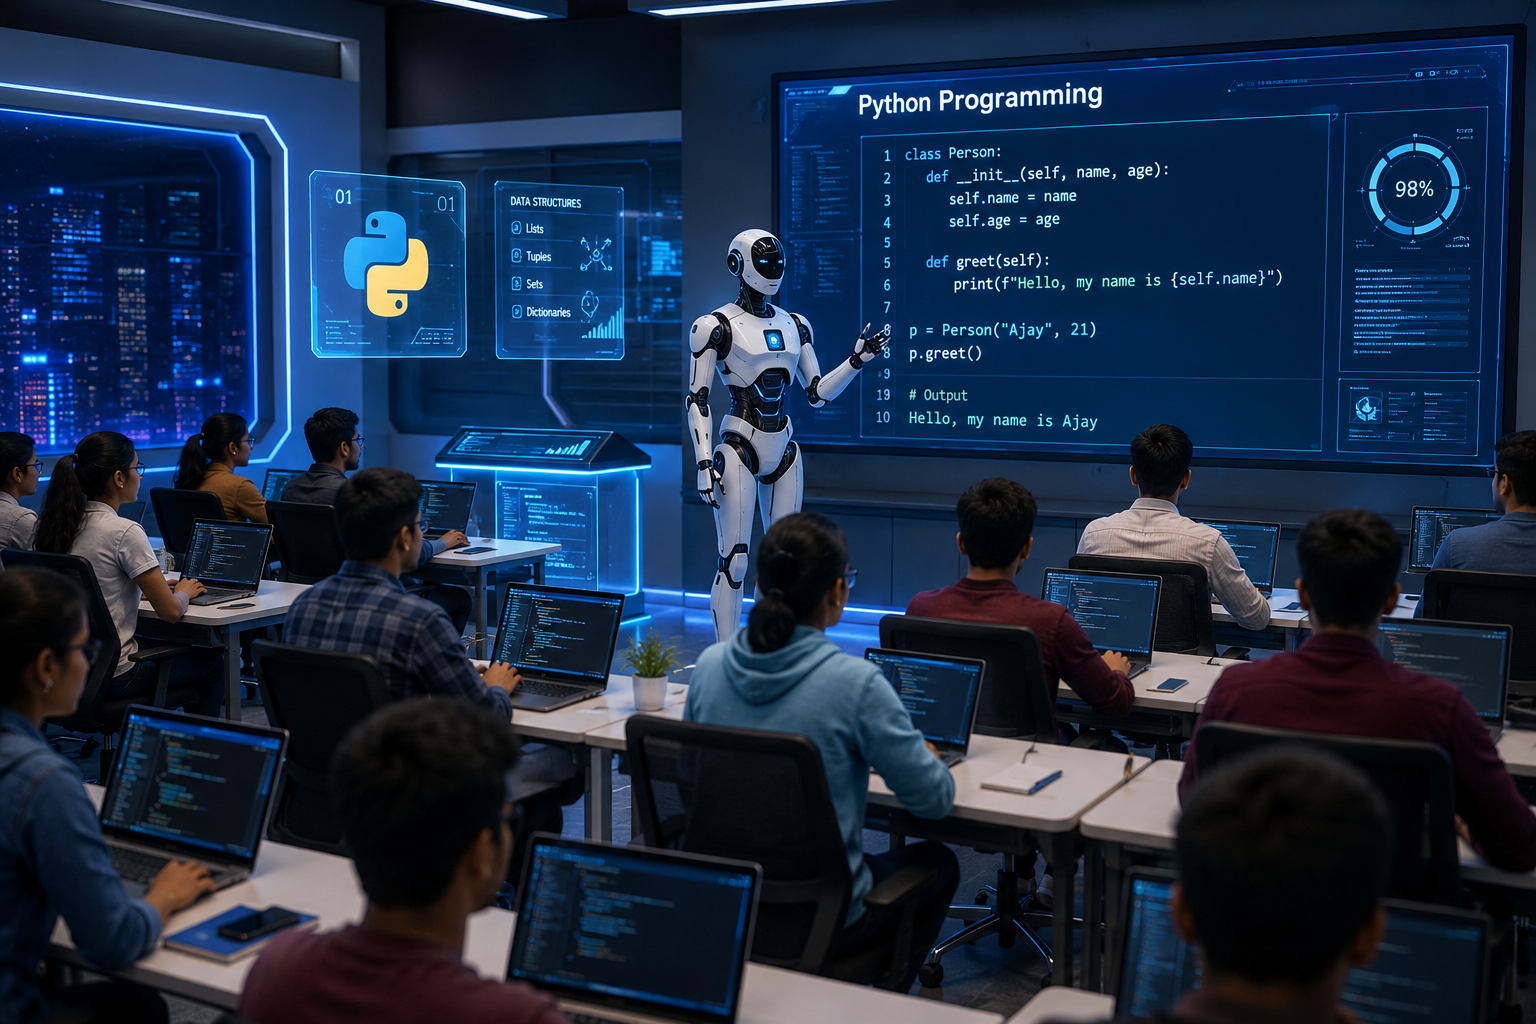

In [ ]:
!pip install pillow
from PIL import Image
image = Image.open("/content/gptimage.png")
image

In [ ]:

analysis_prompt = """
Describe this image in detail.

Mention

- Main objects
- People
- Activities
- Environment
- Colors
- Technology
"""

In [ ]:
from google import genai
from google.genai import types
import os
import google.generativeai as genai
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('apikey1')


In [ ]:
response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=[image, analysis_prompt]
)

caption = response.text

print(caption)

This image depicts a futuristic, high-tech classroom where a humanoid robot is teaching a Python programming class to a group of human students. 

Here is a detailed breakdown of the image:

### **Main Objects**
* **The Humanoid Robot:** Standing at the front-center of the room, acting as the instructor. It has a sleek white and black chassis, articulated joints, a head with a black visor-like face, and a glowing blue circular element on its chest. It is gesturing with its left hand toward the presentation screen.
* **The Presentation Screen:** A massive, high-definition digital board spanning most of the front wall. It displays a Python programming lesson titled **"Python Programming."** The code on the screen shows a basic Object-Oriented Programming (OOP) concept:
  * A class named `Person` with an `__init__` constructor and a `greet` method.
  * An instantiation of the class: `p = Person("Ajay", 21)`.
  * The resulting output: `Hello, my name is Ajay`.
  * The right side of the scr

In [ ]:
print("ORIGINAL PROMPT")
print("="*60)
print(original_prompt)

print("\nGENERATED CAPTION")
print("="*60)
print(caption)

ORIGINAL PROMPT
 A futuristic classroom where an AI humanoid robot teaches Python programming to engineering students. The classroom has - Blue ambient lighting - Interactive holographic displays - Large digital screens - Students working on laptops - Modern smart classroom - Ultra realistic

GENERATED CAPTION
This image depicts a futuristic, high-tech classroom where a humanoid robot is teaching a Python programming class to a group of human students. 

Here is a detailed breakdown of the image:

### **Main Objects**
* **The Humanoid Robot:** Standing at the front-center of the room, acting as the instructor. It has a sleek white and black chassis, articulated joints, a head with a black visor-like face, and a glowing blue circular element on its chest. It is gesturing with its left hand toward the presentation screen.
* **The Presentation Screen:** A massive, high-definition digital board spanning most of the front wall. It displays a Python programming lesson titled **"Python Progra

In [ ]:
evaluation_prompt = f"""
You are an AI evaluator.

Compare the ORIGINAL PROMPT with the GENERATED IMAGE DESCRIPTION.

Original Prompt

{original_prompt}

Generated Caption

{caption}

Evaluate

1. Accuracy (1-5)

2. Relevance (1-5)

3. Completeness (1-5)

4. Missing Objects

5. Alignment Percentage

Return your answer as a table.
"""


In [ ]:
judge = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=evaluation_prompt
)

print(judge.text)

Here is the evaluation of the **Generated Caption** against the **Original Prompt**:

| Evaluation Metric | Score / Value | Justification / Details |
| :--- | :--- | :--- |
| **1. Accuracy (1-5)** | **5/5** | The description is exceptionally accurate. It translates the prompt’s core concepts (like "Python programming" and "interactive holographic displays") into logical visual elements (such as an OOP `Person` class on the screen and floating "Data Structures" menus). |
| **2. Relevance (1-5)** | **5/5** | All details provided in the caption—including the background city view, the robot's design, and the specific Python syntax—directly support the futuristic, high-tech educational theme requested in the prompt. |
| **3. Completeness (1-5)** | **5/5** | The description is fully comprehensive. It leaves no prompt requirements unchecked, elaborating on the classroom, the robot, the students, the laptops, the screens, the holograms, and the lighting. |
| **4. Missing Objects** | **None** |